# Notebook 1: Ingestion & Preprocessing
## Chronicling America 1906 Newspaper Corpus

Converts raw OCR files into a clean preprocessed corpus saved as Parquet.

## Setup

In [1]:
# !pip install pandas pyarrow nltk tqdm

import os
import re
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from tqdm import tqdm

stop_words = set(stopwords.words('english'))
stemmer    = PorterStemmer()

print("ready")

ready


## Config

In [2]:
DATA_DIR = Path("../data/raw")
OUTPUT   = Path("../data/corpus.parquet")

print(f"data dir : {DATA_DIR}")
print(f"output   : {OUTPUT}")

data dir : ../data/raw
output   : ../data/corpus.parquet


## Path Parser

The file path encodes all the metadata we need — newspaper ID, date, edition, page.

In [3]:
# sn########/YYYY/MM/DD/ed-#/seq-#/ocr.txt
PATH_RE = re.compile(r"(sn\d+)/(\d{4})/(\d{2})/(\d{2})/ed-(\d+)/seq-(\d+)/ocr\.txt")

def parse_path(path):
    match = PATH_RE.search(path.as_posix())
    if not match:
        return None
    lccn, year, month, day, edition, page = match.groups()
    return {
        "doc_id"  : f"{lccn}_{year}_{month}_{day}_ed{edition}_seq{page}",
        "lccn"    : lccn,
        "date"    : f"{year}-{month}-{day}",
        "edition" : int(edition),
        "page"    : int(page),
    }

# sanity check
print(parse_path(Path("sn84020235/1906/03/03/ed-1/seq-7/ocr.txt")))

{'doc_id': 'sn84020235_1906_03_03_ed1_seq7', 'lccn': 'sn84020235', 'date': '1906-03-03', 'edition': 1, 'page': 7}


## Preprocessing

Minimal pipeline for noisy historical OCR: lowercase, keep alpha tokens ≥3 chars, remove stopwords, Porter stem.

In [4]:
def clean_text(text):
    lowercased = text.lower()
    all_words = re.findall(r'[a-z]{3,}', lowercased)
    without_stops = [w for w in all_words if w not in stop_words]
    stemmed = [stemmer.stem(w) for w in without_stops]
    return " ".join(stemmed)

# sanity check
raw = "The quick brown fox jumps over the lazy dog. l8o6 ||| OCR garbage!!! TWENTY-THIRD YEAR."
print("RAW    :", raw)
print("CLEANED:", clean_text(raw))

RAW    : The quick brown fox jumps over the lazy dog. l8o6 ||| OCR garbage!!! TWENTY-THIRD YEAR.
CLEANED: quick brown fox jump lazi dog ocr garbag twenti third year


## Load Corpus

In [5]:
ocr_files = sorted(DATA_DIR.rglob("ocr.txt"))
print(f"found {len(ocr_files)} ocr.txt files")

found 608 ocr.txt files


In [6]:
records = []
skipped = 0

for path in tqdm(ocr_files, desc="ingesting"):
    meta = parse_path(path)
    if meta is None:
        skipped += 1
        continue

    raw_text = path.read_text(encoding="utf-8", errors="replace")
    cleaned = clean_text(raw_text)
    token_count = len(cleaned.split())

    records.append({
        "doc_id"      : meta["doc_id"],
        "lccn"        : meta["lccn"],
        "date"        : meta["date"],
        "edition"     : meta["edition"],
        "page"        : meta["page"],
        "raw_text"    : raw_text,
        "clean_text"  : cleaned,
        "token_count" : token_count,
    })

print(f"loaded  : {len(records)}")
print(f"skipped : {skipped}")

ingesting: 100%|██████████████████████████████████████████████████████████████████████| 608/608 [00:06<00:00, 97.70it/s]

loaded  : 608
skipped : 0


## Corpus Stats

In [7]:
df = pd.DataFrame(records)
df["date"] = pd.to_datetime(df["date"])

print(df.shape)
print(f"date range        : {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"unique newspapers : {df['lccn'].nunique()}")
print(f"avg tokens/page   : {df['token_count'].mean():.0f}")
print()
df[["doc_id", "date", "lccn", "page", "token_count"]].head(10)

(608, 8)
date range        : 1906-01-06 -> 1906-12-29
unique newspapers : 2
avg tokens/page   : 2158



,doc_id,date,lccn,page,token_count
0,sn83035387_1906_01_06_ed1_seq1,1906-01-06,sn83035387,1,3239
1,sn83035387_1906_01_06_ed1_seq2,1906-01-06,sn83035387,2,3700
2,sn83035387_1906_01_06_ed1_seq3,1906-01-06,sn83035387,3,2568
3,sn83035387_1906_01_06_ed1_seq4,1906-01-06,sn83035387,4,2696
4,sn83035387_1906_01_13_ed1_seq1,1906-01-13,sn83035387,1,3260
5,sn83035387_1906_01_13_ed1_seq2,1906-01-13,sn83035387,2,3677
6,sn83035387_1906_01_13_ed1_seq3,1906-01-13,sn83035387,3,2485
7,sn83035387_1906_01_13_ed1_seq4,1906-01-13,sn83035387,4,3249
8,sn83035387_1906_01_20_ed1_seq1,1906-01-20,sn83035387,1,3386
9,sn83035387_1906_01_20_ed1_seq2,1906-01-20,sn83035387,2,3415


In [8]:
# token count before and after preprocessing
df['raw_len'] = df['raw_text'].str.split().apply(len)
df['clean_len'] = df['clean_text'].str.split().apply(len)

print(f"avg raw tokens   : {df['raw_len'].mean():.0f}")
print(f"avg clean tokens : {df['clean_len'].mean():.0f}")
print(f"reduction        : {100 * (1 - df['clean_len'].mean() / df['raw_len'].mean()):.1f}%")
print()
print(df[['raw_len', 'clean_len']].describe().round(2))

avg raw tokens   : 4033
avg clean tokens : 2158
reduction        : 46.5%

       raw_len  clean_len
count   608.00     608.00
mean   4032.55    2157.50
std    1283.29     713.89
min    1352.00     712.00
25%    2959.00    1559.50
50%    3921.00    2053.00
75%    5012.25    2707.50
max    7251.00    3930.00


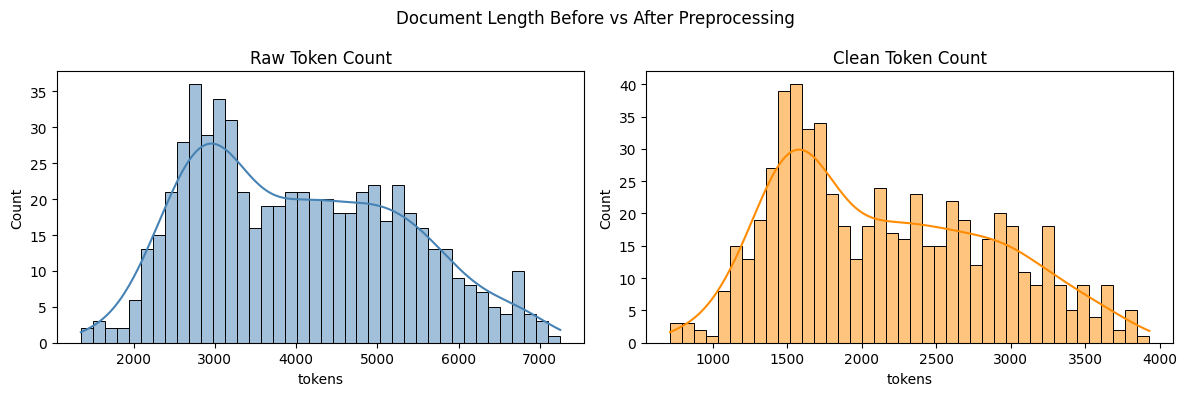

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['raw_len'],   bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Raw Token Count")
axes[0].set_xlabel("tokens")

sns.histplot(df['clean_len'], bins=40, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title("Clean Token Count")
axes[1].set_xlabel("tokens")

plt.suptitle("Document Length Before vs After Preprocessing")
plt.tight_layout()
plt.show()

## Vocabulary Analysis

In [10]:
flat_tokens   = [t for text in df['clean_text'] for t in text.split()]
vocab_counter = Counter(flat_tokens)

print(f"total tokens  : {len(flat_tokens):,}")
print(f"unique tokens : {len(vocab_counter):,}")
print(f"TTR           : {len(vocab_counter) / len(flat_tokens):.4f}")

total tokens  : 1,311,763
unique tokens : 55,366
TTR           : 0.0422


In [11]:
# top 25 terms after preprocessing
pd.DataFrame(vocab_counter.most_common(25), columns=["term", "frequency"])

,term,frequency
0,mr,12477
1,one,6976
2,street,6506
3,year,5241
4,day,4636
5,citi,4544
6,loui,4486
7,new,4389
8,state,4088
9,miss,4052


/var/folders/58/l9vd2cxj65ldm1htp9rssjb40000gn/T/ipykernel_65204/1123607162.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(terms), y=list(freqs), palette="viridis")


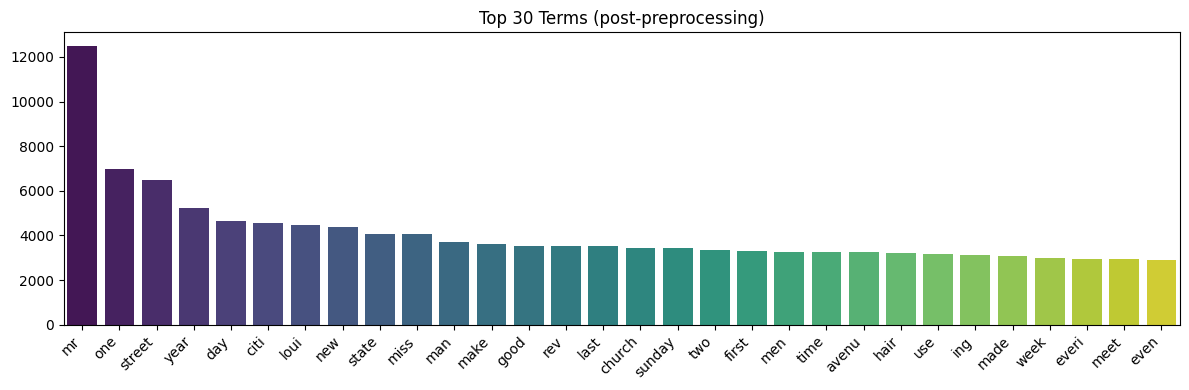

In [12]:
# top 30 bar chart
terms, freqs = zip(*vocab_counter.most_common(30))
plt.figure(figsize=(12, 4))
sns.barplot(x=list(terms), y=list(freqs), palette="viridis")
plt.title("Top 30 Terms (post-preprocessing)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Save

In [13]:
df.drop(columns=["raw_len", "clean_len"]).to_parquet(OUTPUT, index=False)
print(f"saved -> {OUTPUT}  ({OUTPUT.stat().st_size / 1024:.1f} KB)")

saved -> ../data/corpus.parquet  (14388.7 KB)
